In [7]:
import yaml
import numpy as np
from matplotlib import pyplot as plt

# --- Custom Utility Module --
from flux_history import FluxHistory
from mineral_utils import Paleodetector

In [8]:
mineral_name =  "Olivine"

overburden_history = {
    "initial_depth": 0.15
}

time = 1. / (24 * 365.25 * 1e3)

h_obs_km = 11.

flux_history_flight  = FluxHistory(baseline={"kind": "Baseline", "h_obs_km": h_obs_km})

In [9]:
MINERAL_LIBRARY = yaml.safe_load(open('Data/mineral_library.yaml', 'r'))
mineral_config = MINERAL_LIBRARY.get(mineral_name)


mineral_flight = Paleodetector(mineral_config, total_age_kyr=time, flux_history=flux_history_flight, overburden_history=overburden_history)

Interpolating overburden history...
Initialized Paleodetector: Olivine


In [10]:
x_bins, tracks_flight = mineral_flight.integrate_all_particles()

100%|██████████| 4/4 [02:57<00:00, 44.27s/it] 


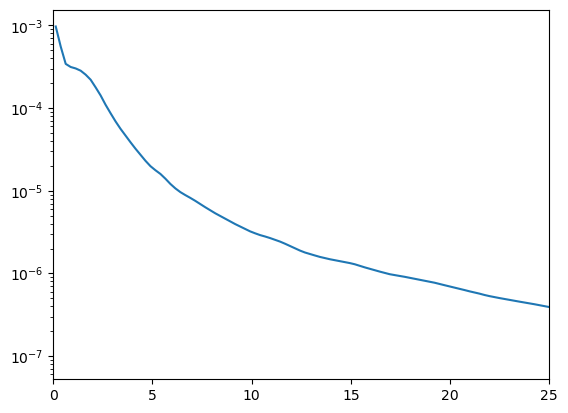

In [11]:
x_mids = x_bins[:-1] + np.diff(x_bins) / 2     

plt.plot(x_mids/1000., tracks_flight["total"], label = "1hr flight")
plt.xlim(0, 25.)
plt.yscale('log')

In [12]:
tracks_flight["x_bins"] = x_bins

np.savez(f"Data/tracks_{mineral_name}_1hr{h_obs_km}km_flight", tracks_flight)